In [143]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed = 42
np.random.seed(seed)

In [144]:
df = pd.read_csv('data/mobile_price.csv')
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [145]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in df.columns if c not in ['price_range']]

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
 
X = df[feature_cols].values.astype(float)
y = df['price_range'].values

X, X_val, y, y_val = train_test_split(X, y, test_size=0.2, random_state=seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)


In [146]:
model_initial = SVC(C=1.0, random_state=seed)
model_initial.fit(X_train, y_train)

def get_metrics(model, X, y):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average='weighted')
    return acc, f1

# Report results
sets = [(X_train, y_train, "Train"), (X_val, y_val, "Val"), (X_test, y_test, "Test")]
for data, labels, name in sets:
    acc, f1 = get_metrics(model_initial, data, labels)
    print(f"{name} -> Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")

Train -> Accuracy: 0.9680, F1-Score: 0.9681
Val -> Accuracy: 0.8675, F1-Score: 0.8684
Test -> Accuracy: 0.8562, F1-Score: 0.8577


In [147]:
C_value = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
result = []

for c in C_value:
    svc = SVC(C=c, random_state=seed)
    svc.fit(X_train, y_train)

    train_acc, train_f1 = get_metrics(svc, X_train, y_train)
    val_acc, val_f1 = get_metrics(svc, X_val, y_val)
    test_acc, test_f1 = get_metrics(svc, X_test, y_test)
    
    print(F"C = {c}")
    print(f"Train -> Accuracy: {train_acc:.4f}, F1-Score: {train_f1:.4f}")
    print(f"Val -> Accuracy: {val_acc:.4f}, F1-Score: {val_f1:.4f}")
    print(f"Test -> Accuracy: {test_acc:.4f}, F1-Score: {test_f1:.4f}\n")

    result.append({
        'C': c,
        'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc,
        'train_f1': train_f1, 'val_f1': val_f1, 'test_f1': test_f1
    })
res_df = pd.DataFrame(result)




C = 0.001
Train -> Accuracy: 0.2625, F1-Score: 0.1092
Val -> Accuracy: 0.2275, F1-Score: 0.0843
Test -> Accuracy: 0.2281, F1-Score: 0.0847

C = 0.01
Train -> Accuracy: 0.2625, F1-Score: 0.1092
Val -> Accuracy: 0.2275, F1-Score: 0.0843
Test -> Accuracy: 0.2281, F1-Score: 0.0847

C = 0.1
Train -> Accuracy: 0.3227, F1-Score: 0.2151
Val -> Accuracy: 0.2625, F1-Score: 0.1482
Test -> Accuracy: 0.2625, F1-Score: 0.1546

C = 1
Train -> Accuracy: 0.9680, F1-Score: 0.9681
Val -> Accuracy: 0.8675, F1-Score: 0.8684
Test -> Accuracy: 0.8562, F1-Score: 0.8577

C = 10
Train -> Accuracy: 1.0000, F1-Score: 1.0000
Val -> Accuracy: 0.8725, F1-Score: 0.8735
Test -> Accuracy: 0.8531, F1-Score: 0.8535

C = 100
Train -> Accuracy: 1.0000, F1-Score: 1.0000
Val -> Accuracy: 0.8600, F1-Score: 0.8611
Test -> Accuracy: 0.8500, F1-Score: 0.8501

C = 1000
Train -> Accuracy: 1.0000, F1-Score: 1.0000
Val -> Accuracy: 0.8600, F1-Score: 0.8611
Test -> Accuracy: 0.8500, F1-Score: 0.8501

C = 10000
Train -> Accuracy: 1.00

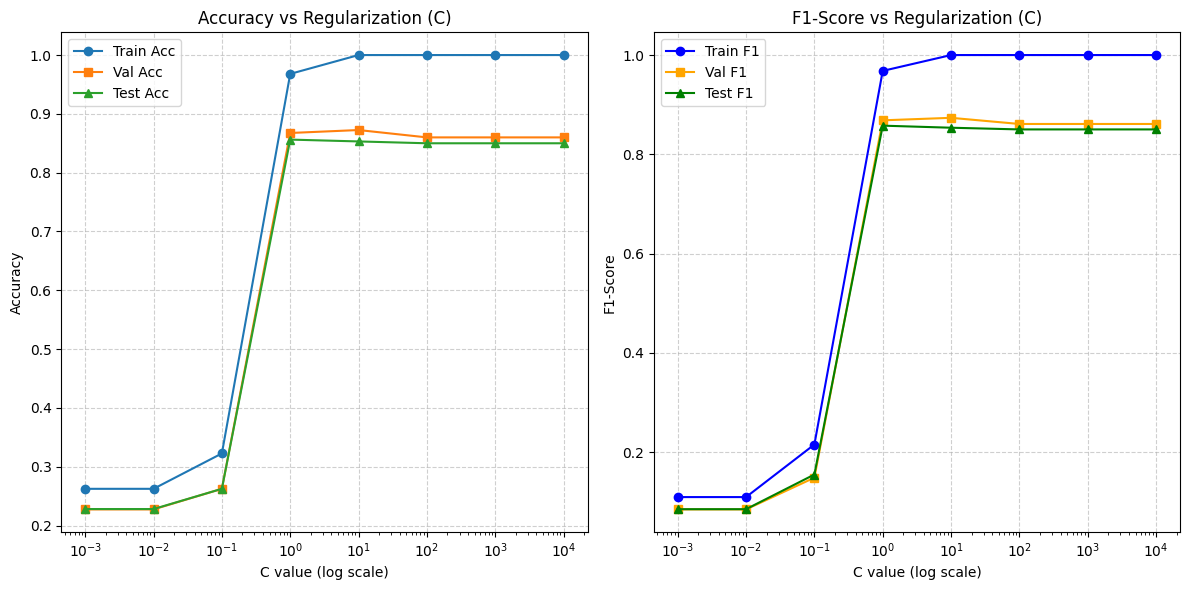

In [148]:
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(res_df['C'], res_df['train_acc'], marker='o', label='Train Acc')
plt.plot(res_df['C'], res_df['val_acc'], marker='s', label='Val Acc')
plt.plot(res_df['C'], res_df['test_acc'], marker='^', label='Test Acc')
plt.xscale('log')
plt.title('Accuracy vs Regularization (C)')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot F1-Score
plt.subplot(1, 2, 2)
plt.plot(res_df['C'], res_df['train_f1'], marker='o', label='Train F1', color='blue')
plt.plot(res_df['C'], res_df['val_f1'], marker='s', label='Val F1', color='orange')
plt.plot(res_df['C'], res_df['test_f1'], marker='^', label='Test F1', color='green')
plt.xscale('log')
plt.title('F1-Score vs Regularization (C)')
plt.xlabel('C value (log scale)')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [149]:
%pip install mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [150]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

df_filtered = df[df['price_range'] == 1][['ram', 'int_memory', 'px_width', 'battery_power']].copy()

# Function to categorize based on 3:4:3 ratio of the RANGE
def categorize_343(series, name):
    min_val = series.min()
    max_val = series.max()
    total_range = max_val - min_val
    
    # Define thresholds
    low_thresh = min_val + (0.3 * total_range)
    high_thresh = min_val + (0.7 * total_range) # 0.3 (low) + 0.4 (medium) = 0.7
    
    def get_label(val):
        if val <= low_thresh: return f"{name}_low"
        elif val <= high_thresh: return f"{name}_medium"
        else: return f"{name}_high"
    
    return series.apply(get_label)

# Apply categorization
for col in df_filtered.columns:
    df_filtered[col] = categorize_343(df_filtered[col], col)

# Convert to list of transactions
transactions = df_filtered.values.tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_onehot = pd.DataFrame(te_ary, columns=te.columns_)

In [151]:
# Generate frequent itemsets
frequent_itemsets = fpgrowth(df_onehot, min_support=0.3, use_colnames=True)

print("Frequent Patterns (Support >= 0.3):")
display(frequent_itemsets.sort_values(by='support', ascending=False))

Frequent Patterns (Support >= 0.3):


,support,itemsets
2,0.682,frozenset({ram_medium})
3,0.416,frozenset({px_width_medium})
5,0.414,frozenset({battery_power_medium})
4,0.412,frozenset({int_memory_medium})
7,0.318,"frozenset({ram_medium, battery_power_medium})"
0,0.316,frozenset({int_memory_low})
1,0.308,frozenset({battery_power_low})
6,0.306,"frozenset({ram_medium, px_width_medium})"


In [152]:
# Generate rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

# Filter by your Lift and Support requirements
filtered_rules = rules[(rules['support'] >= 0.3) & (rules['lift'] >= 0.8)]

print("\nAssociation Rules (Support >= 0.3, Confidence >= 0.4, Lift >= 0.8):")
display(filtered_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Association Rules (Support >= 0.3, Confidence >= 0.4, Lift >= 0.8):


,antecedents,consequents,support,confidence,lift
0,frozenset({ram_medium}),frozenset({px_width_medium}),0.306,0.448680,1.078559
1,frozenset({px_width_medium}),frozenset({ram_medium}),0.306,0.735577,1.078559
2,frozenset({ram_medium}),frozenset({battery_power_medium}),0.318,0.466276,1.126270
3,frozenset({battery_power_medium}),frozenset({ram_medium}),0.318,0.768116,1.126270


In [153]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

X = df.drop('price_range', axis=1)
y = df['price_range']

# Z-score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

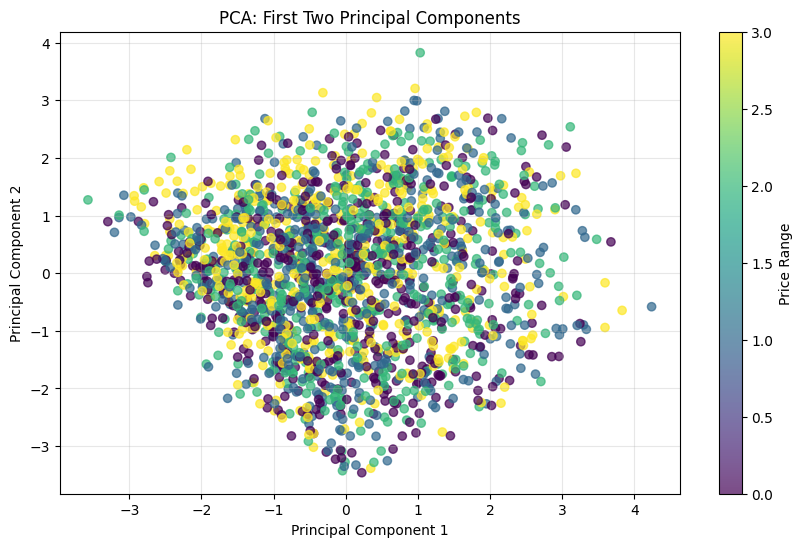

In [154]:
# Project onto 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualization
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Price Range')
plt.title('PCA: First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()

K-means (Full Features) Adjusted Rand Score: 0.0060


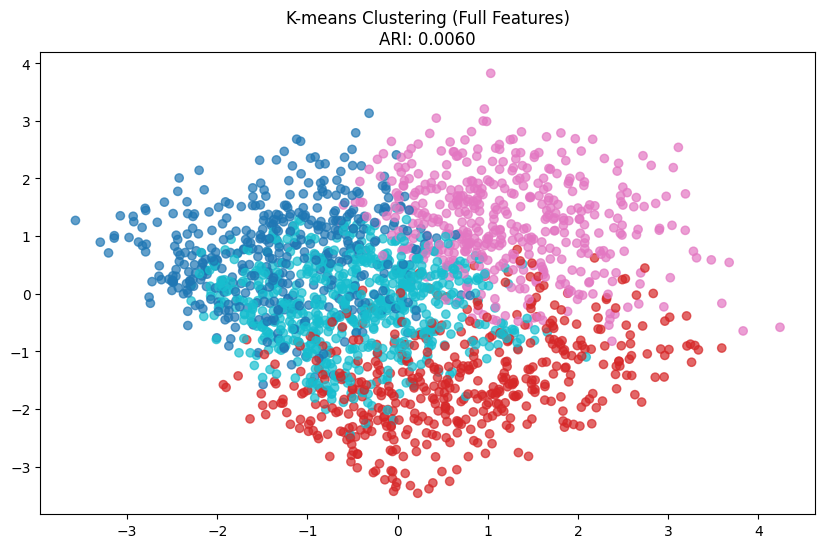

In [155]:
# Apply K-means (4 clusters)
kmeans_full = KMeans(n_clusters=4, random_state=seed, n_init=10)
y_kmeans_full = kmeans_full.fit_predict(X_scaled)

# Evaluate performance
ari_full = adjusted_rand_score(y, y_kmeans_full)
print(f"K-means (Full Features) Adjusted Rand Score: {ari_full:.4f}")

# Visualize (using PCA coordinates for plotting purposes)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans_full, cmap='tab10', alpha=0.7)
plt.title(f'K-means Clustering (Full Features)\nARI: {ari_full:.4f}')
plt.show()

K-means (PCA 2D Features) Adjusted Rand Score: 0.0017


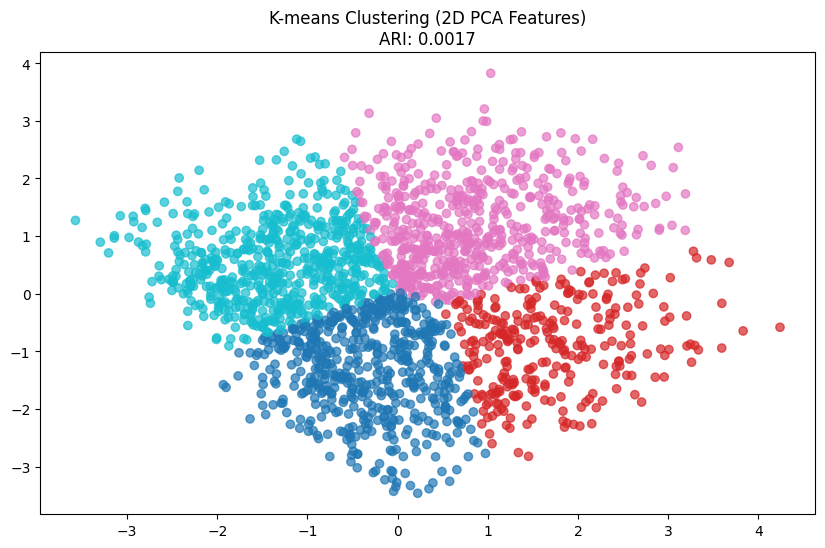

In [156]:
# Apply K-means on the 2D PCA data
kmeans_pca = KMeans(n_clusters=4, random_state=seed, n_init=10)
y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Evaluate performance
ari_pca = adjusted_rand_score(y, y_kmeans_pca)
print(f"K-means (PCA 2D Features) Adjusted Rand Score: {ari_pca:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans_pca, cmap='tab10', alpha=0.7)
plt.title(f'K-means Clustering (2D PCA Features)\nARI: {ari_pca:.4f}')
plt.show()

K-means (Full Features Normalized) Adjusted Rand Score: 0.0060


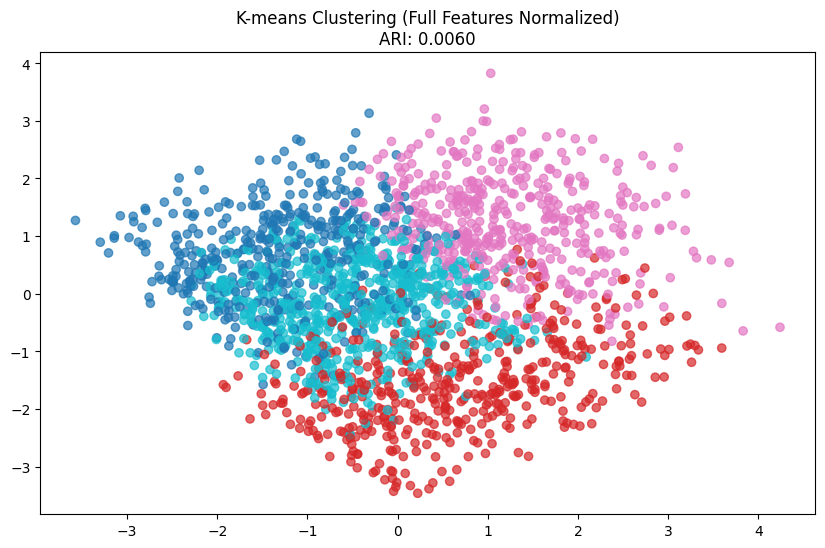

In [157]:
feature_cols = [c for c in df.columns if c not in ['price_range']]

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
 
X = df[feature_cols].values.astype(float)
y = df['price_range'].values

# Z-score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means (4 clusters)
kmeans_full = KMeans(n_clusters=4, random_state=seed, n_init=10)
y_kmeans_full = kmeans_full.fit_predict(X_scaled)

# Evaluate performance
ari_full = adjusted_rand_score(y, y_kmeans_full)
print(f"K-means (Full Features Normalized) Adjusted Rand Score: {ari_full:.4f}")

# Visualize (using PCA coordinates for plotting purposes)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans_full, cmap='tab10', alpha=0.7)
plt.title(f'K-means Clustering (Full Features Normalized)\nARI: {ari_full:.4f}')
plt.show()

In [159]:
from sklearn.metrics import precision_score, recall_score
from scipy.optimize import linear_sum_assignment

new_seeds = [0, 10, 42, 100, 999]
X = df.drop('price_range', axis=1)
y = df['price_range']

# Discretize to find which features correlate with price
X_disc = df.copy()
for col in X_disc.columns:
    X_disc[col] = categorize_343(X_disc[col], col)
transactions = X_disc.apply(lambda x: [f"{col}_{val}" for col, val in x.items()], axis=1).tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_te = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = fpgrowth(df_te, min_support=0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Extract weights: average lift of rules involving a feature and price_range
feature_weights = {col: 1.0 for col in X.columns}
for col in X.columns:
    relevant_rules = rules[rules['antecedents'].apply(lambda x: any(col in item for item in x)) & 
                           rules['consequents'].apply(lambda x: any('price_range' in item for item in x))]
    if not relevant_rules.empty:
        feature_weights[col] = relevant_rules['lift'].mean()

weight_vector = np.array([feature_weights[col] for col in X.columns])

# Evaluation Function (Maps Clusters to Labels)
def evaluate_clustering(y_true, y_pred):
    # Create a confusion matrix to align clusters with labels
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1
    # Use Hungarian Algorithm for optimal mapping
    row_ind, col_ind = linear_sum_assignment(w.max() - w)
    
    # Map clusters to true labels
    mapping = {row: col for row, col in zip(row_ind, col_ind)}
    y_mapped = np.array([mapping[cluster] for cluster in y_pred])
    
    return {
        'acc': accuracy_score(y_true, y_mapped),
        'prec': precision_score(y_true, y_mapped, average='weighted'),
        'rec': recall_score(y_true, y_mapped, average='weighted'),
        'f1': f1_score(y_true, y_mapped, average='weighted')
    }

# Comparison Loop
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_weighted = X_scaled * weight_vector

orig_results, imp_results = [], []

for seed in new_seeds:
    # Original K-means
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_scaled)
    orig_results.append(evaluate_clustering(y, km_orig))
    
    # Improved K-means
    km_imp = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_weighted)
    imp_results.append(evaluate_clustering(y, km_imp))

# Report Averages
def get_avg(res_list):
    return {k: np.mean([r[k] for r in res_list]) for k in res_list[0].keys()}

avg_orig = get_avg(orig_results)
avg_imp = get_avg(imp_results)

print("--- Comparison Results ---")
print(f"Metric\t\tOriginal\tImproved")
for m in avg_orig.keys():
    print(f"{m.upper()}\t\t{avg_orig[m]:.4f}\t\t{avg_imp[m]:.4f}")

--- Comparison Results ---
Metric		Original	Improved
ACC		0.2962		0.4493
PREC		0.2959		0.4322
REC		0.2962		0.4493
F1		0.2941		0.4368


In [160]:
# Extract weights: average lift of rules involving a feature and price_range
feature_weights = {col: 1.0 for col in X.columns}
for col in X.columns:
    relevant_rules = rules[rules['antecedents'].apply(lambda x: any(col in item for item in x)) & 
                           rules['consequents'].apply(lambda x: any('price_range' in item for item in x))]
    if not relevant_rules.empty:
        feature_weights[col] = np.power(relevant_rules['lift'].mean(),2)

weight_vector = np.array([feature_weights[col] for col in X.columns])

# Comparison Loop
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_weighted = X_scaled * weight_vector

orig_results, imp_results = [], []

for seed in new_seeds:
    # Original K-means
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_scaled)
    orig_results.append(evaluate_clustering(y, km_orig))
    
    # Improved K-means
    km_imp = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_weighted)
    imp_results.append(evaluate_clustering(y, km_imp))

avg_orig = get_avg(orig_results)
avg_imp = get_avg(imp_results)

print("--- Comparison Results ---")
print(f"Metric\t\tOriginal\tImproved")
for m in avg_orig.keys():
    print(f"{m.upper()}\t\t{avg_orig[m]:.4f}\t\t{avg_imp[m]:.4f}")

--- Comparison Results ---
Metric		Original	Improved
ACC		0.2962		0.6093
PREC		0.2959		0.5918
REC		0.2962		0.6093
F1		0.2941		0.5946


In [ ]:
frequent_itemsets = fpgrowth(df_te, min_support=0.3, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Extract weights: average lift of rules involving a feature and price_range
feature_weights = {col: 1.0 for col in X.columns}
for col in X.columns:
    relevant_rules = rules[rules['antecedents'].apply(lambda x: any(col in item for item in x)) & 
                           rules['consequents'].apply(lambda x: any('price_range' in item for item in x))]
    if not relevant_rules.empty:
        feature_weights[col] = np.power(relevant_rules['lift'].mean(),2)

weight_vector = np.array([feature_weights[col] for col in X.columns])

# Comparison Loop
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_weighted = X_scaled * weight_vector

orig_results, imp_results = [], []

for seed in new_seeds:
    # Original K-means
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_scaled)
    orig_results.append(evaluate_clustering(y, km_orig))
    
    # Improved K-means
    km_imp = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_weighted)
    imp_results.append(evaluate_clustering(y, km_imp))

avg_orig = get_avg(orig_results)
avg_imp = get_avg(imp_results)

print("--- Comparison Results ---")
print(f"Metric\t\tOriginal\tImproved")
for m in avg_orig.keys():
    print(f"{m.upper()}\t\t{avg_orig[m]:.4f}\t\t{avg_imp[m]:.4f}")

--- Comparison Results ---
Metric		Original	Improved
ACC		0.2962		0.6453
PREC		0.2959		0.6200
REC		0.2962		0.6453
F1		0.2941		0.6211


In [173]:
conf_rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

# Extract weights: average lift of rules involving a feature and price_range
feature_weights = {col: 1.0 for col in X.columns}
for col in X.columns:
    relevant_rules = conf_rules[conf_rules['antecedents'].apply(lambda x: any(col in item for item in x)) & 
                                conf_rules['consequents'].apply(lambda x: any('price_range' in item for item in x))]
    if not relevant_rules.empty:
        feature_weights[col] = np.power(relevant_rules['lift'].mean(),2)

weight_vector = np.array([feature_weights[col] for col in X.columns])

# Comparison Loop
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_weighted = X_scaled * weight_vector

orig_results, imp_results = [], []

for seed in new_seeds:
    # Original K-means
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_scaled)
    orig_results.append(evaluate_clustering(y, km_orig))
    
    # Improved K-means
    km_imp = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_weighted)
    imp_results.append(evaluate_clustering(y, km_imp))

avg_orig = get_avg(orig_results)
avg_imp = get_avg(imp_results)

print("--- Comparison Results ---")
print(f"Metric\t\tOriginal\tImproved")
for m in avg_orig.keys():
    print(f"{m.upper()}\t\t{avg_orig[m]:.4f}\t\t{avg_imp[m]:.4f}")

--- Comparison Results ---
Metric		Original	Improved
ACC		0.2962		0.6476
PREC		0.2959		0.6253
REC		0.2962		0.6476
F1		0.2941		0.6256


In [163]:
# Extract weights: average lift of rules involving a feature and price_range
feature_weights = {col: 0.1 for col in X.columns}
for col in X.columns:
    relevant_rules = rules[rules['antecedents'].apply(lambda x: any(col in item for item in x)) & 
                           rules['consequents'].apply(lambda x: any('price_range' in item for item in x))]
    if not relevant_rules.empty:
        feature_weights[col] = np.power(relevant_rules['lift'].mean(),2)

weight_vector = np.array([feature_weights[col] for col in X.columns])

# Comparison Loop
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_weighted = X_scaled * weight_vector

orig_results, imp_results = [], []

for seed in new_seeds:
    # Original K-means
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_scaled)
    orig_results.append(evaluate_clustering(y, km_orig))
    
    # Improved K-means
    km_imp = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_weighted)
    imp_results.append(evaluate_clustering(y, km_imp))

avg_orig = get_avg(orig_results)
avg_imp = get_avg(imp_results)

print("--- Comparison Results ---")
print(f"Metric\t\tOriginal\tImproved")
for m in avg_orig.keys():
    print(f"{m.upper()}\t\t{avg_orig[m]:.4f}\t\t{avg_imp[m]:.4f}")

--- Comparison Results ---
Metric		Original	Improved
ACC		0.2962		0.7536
PREC		0.2959		0.7571
REC		0.2962		0.7536
F1		0.2941		0.7546


In [164]:
# Extract weights: average lift of rules involving a feature and price_range
feature_weights = {col: 10 for col in X.columns}
for col in X.columns:
    relevant_rules = rules[rules['antecedents'].apply(lambda x: any(col in item for item in x)) & 
                           rules['consequents'].apply(lambda x: any('price_range' in item for item in x))]
    if not relevant_rules.empty:
        feature_weights[col] = np.power(relevant_rules['lift'].mean(),2)

weight_vector = np.array([feature_weights[col] for col in X.columns])

# Comparison Loop
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_weighted = X_scaled * weight_vector

orig_results, imp_results = [], []

for seed in new_seeds:
    # Original K-means
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_scaled)
    orig_results.append(evaluate_clustering(y, km_orig))
    
    # Improved K-means
    km_imp = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_weighted)
    imp_results.append(evaluate_clustering(y, km_imp))

avg_orig = get_avg(orig_results)
avg_imp = get_avg(imp_results)

print("--- Comparison Results ---")
print(f"Metric\t\tOriginal\tImproved")
for m in avg_orig.keys():
    print(f"{m.upper()}\t\t{avg_orig[m]:.4f}\t\t{avg_imp[m]:.4f}")

--- Comparison Results ---
Metric		Original	Improved
ACC		0.2962		0.2911
PREC		0.2959		0.2923
REC		0.2962		0.2911
F1		0.2941		0.2909


In [165]:
# Extract weights: average lift of rules involving a feature and price_range
feature_weights = {col: 0.1 for col in X.columns}
for col in X.columns:
    relevant_rules = conf_rules[conf_rules['antecedents'].apply(lambda x: any(col in item for item in x)) & 
                                conf_rules['consequents'].apply(lambda x: any('price_range' in item for item in x))]
    if not relevant_rules.empty:
        feature_weights[col] = np.power(relevant_rules['lift'].mean(),2)

weight_vector = np.array([feature_weights[col] for col in X.columns])

# Comparison Loop
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_weighted = X_scaled * weight_vector

orig_results, imp_results = [], []

for seed in new_seeds:
    # Original K-means
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_scaled)
    orig_results.append(evaluate_clustering(y, km_orig))
    
    # Improved K-means
    km_imp = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_weighted)
    imp_results.append(evaluate_clustering(y, km_imp))

avg_orig = get_avg(orig_results)
avg_imp = get_avg(imp_results)

print("--- Comparison Results ---")
print(f"Metric\t\tOriginal\tImproved")
for m in avg_orig.keys():
    print(f"{m.upper()}\t\t{avg_orig[m]:.4f}\t\t{avg_imp[m]:.4f}")

--- Comparison Results ---
Metric		Original	Improved
ACC		0.2962		0.7515
PREC		0.2959		0.7551
REC		0.2962		0.7515
F1		0.2941		0.7525


In [166]:
feature_weights = {col: 0.1 for col in X.columns}
for col in X.columns:
    relevant_rules = rules[rules['antecedents'].apply(lambda x: col in str(x)) & 
                           rules['consequents'].apply(lambda x: 'price_range' in str(x))]
    
    if not relevant_rules.empty:
        deviations = relevant_rules['lift'].apply(lambda x: abs(x - 1.0))
        feature_weights[col] = (deviations.max() + 1.0) ** 2

# Comparison Loop
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_weighted = X_scaled * weight_vector

orig_results, imp_results = [], []

for seed in new_seeds:
    # Original K-means
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_scaled)
    orig_results.append(evaluate_clustering(y, km_orig))
    
    # Improved K-means
    km_imp = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_weighted)
    imp_results.append(evaluate_clustering(y, km_imp))

avg_orig = get_avg(orig_results)
avg_imp = get_avg(imp_results)

print("--- Comparison Results ---")
print(f"Metric\t\tOriginal\tImproved")
for m in avg_orig.keys():
    print(f"{m.upper()}\t\t{avg_orig[m]:.4f}\t\t{avg_imp[m]:.4f}")

--- Comparison Results ---
Metric		Original	Improved
ACC		0.2962		0.7515
PREC		0.2959		0.7551
REC		0.2962		0.7515
F1		0.2941		0.7525


In [167]:
initial_centroids = []

for i in range(4): # For each price_range 0-3
    target_label = f'price_range_{i}'
    # Find rules that lead to this specific price range
    specific_rules = rules[rules['consequents'].apply(lambda x: target_label in str(x))]
    
    if not specific_rules.empty:
        # Get the antecedent of the best rule
        best_ante = list(specific_rules.loc[specific_rules['lift'].idxmax()]['antecedents'])
        
        # Find samples in the DISCRETIZED data that match this rule
        # (Assuming X_disc is your discretized dataframe)
        matches = X_disc[X_disc.apply(lambda row: all(item.split('_')[-1] in str(row[item.rsplit('_', 1)[0]]) 
                                                  for item in best_ante), axis=1)]
        
        if len(matches) > 0:
            # Take the mean of these phones in the WEIGHTED numerical space
            centroid = X_weighted[matches.index].mean(axis=0)
            initial_centroids.append(centroid)
        else:
            # Fallback if no exact matches: use global mean of the weighted data
            initial_centroids.append(X_weighted.mean(axis=0))
    else:
        # Fallback if no rules for this class
        initial_centroids.append(X_weighted[i*500]) # Pick a sample far apart

initial_centroids = np.array(initial_centroids)

# Run K-Means with the 'init' parameter
# Note: n_init must be 1 when providing manual centers
km_final = KMeans(n_clusters=4, init=initial_centroids, n_init=1, random_state=42)
y_pred = km_final.fit_predict(X_weighted)

orig_results, seed_results = [], []

for seed in new_seeds:
    # 1. Original K-means (Standard)
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_scaled)
    orig_results.append(evaluate_clustering(y, km_orig))
    
    # 2. Improved K-means (Weighting + Informed Seeding)
    # We use n_init=1 because we are providing the starting points
    km_seed = KMeans(n_clusters=4, init=initial_centroids, n_init=1, random_state=seed).fit_predict(X_weighted)
    seed_results.append(evaluate_clustering(y, km_seed))

# --- Part C: Performance Reporting ---
avg_orig = get_avg(orig_results)
avg_seed = get_avg(seed_results)

print("--- Comparison Results (With Informed Seeding) ---")
print(f"Metric\t\tOriginal\tSeed-Improved")
for m in avg_orig.keys():
    print(f"{m.upper()}\t\t{avg_orig[m]:.4f}\t\t{avg_seed[m]:.4f}")

--- Comparison Results (With Informed Seeding) ---
Metric		Original	Seed-Improved
ACC		0.2962		0.7535
PREC		0.2959		0.7568
REC		0.2962		0.7535
F1		0.2941		0.7546


In [168]:
# Define the Ladder thresholds
top_threshold = rules['lift'].quantile(0.90) # Top 10% of rules

feature_weights = {}

for col in X.columns:
    relevant_rules = rules[rules['antecedents'].apply(lambda x: any(col in item for item in x)) & 
                           rules['consequents'].apply(lambda x: any('price_range' in item for item in x))]
    
    if not relevant_rules.empty:
        max_lift = relevant_rules['lift'].max()
        
        if max_lift >= top_threshold:
            # TIER 1: The Heroes (Top 10% impactful features)
            feature_weights[col] = np.power(max_lift, 3) 
        else:
            # TIER 2: The Supporters (Normal associated features)
            feature_weights[col] = np.power(max_lift, 2)
    else:
        # TIER 3: The Noise (Completely irrelevant to price)
        feature_weights[col] = 0.01 # Aggressive suppression

weight_vector = np.array([feature_weights[col] for col in X.columns])
X_weighted_ladder = X_scaled * weight_vector

# Run K-means on X_weighted_ladder
# Run K-means on X_weighted_interaction
orig_results, imp_results = [], []

for seed in new_seeds:
    # Original K-means
    km_orig = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_scaled)
    orig_results.append(evaluate_clustering(y, km_orig))
    
    # Improved K-means
    km_imp = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(X_weighted_ladder)
    imp_results.append(evaluate_clustering(y, km_imp))

avg_orig = get_avg(orig_results)
avg_imp = get_avg(imp_results)

print("--- Comparison Results ---")
print(f"Metric\t\tOriginal\tImproved")
for m in avg_orig.keys():
    print(f"{m.upper()}\t\t{avg_orig[m]:.4f}\t\t{avg_imp[m]:.4f}")

--- Comparison Results ---
Metric		Original	Improved
ACC		0.2962		0.7514
PREC		0.2959		0.7553
REC		0.2962		0.7514
F1		0.2941		0.7524
